# Análise dos resultados
Notebook para consolidar gráficos e discutir os resultados obtidos.

In [3]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

base = Path("..")
results_dir = base / "results"
resnet_path = results_dir / "pretrained_test_metrics.json"
cnn_path = results_dir / "cnn_test_metrics.json"

def _load_results(path: Path, model_name: str) -> list:
    data = json.loads(path.read_text(encoding="utf-8"))
    rows = []
    for dataset_name, metrics in data.items():
        rows.append({
            "model": model_name,
            "dataset": dataset_name,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1_score": metrics["f1_score"],
            "confusion_matrix": metrics["confusion_matrix"],
            "class_names": metrics["class_names"],
        })
    return rows

results_rows = []
if resnet_path.exists():
    results_rows += _load_results(resnet_path, "ResNet50")
else:
    print(f"Arquivo nao encontrado: {resnet_path}")

if cnn_path.exists():
    results_rows += _load_results(cnn_path, "CNN")
else:
    print(f"Arquivo nao encontrado: {cnn_path}")

results_df = pd.DataFrame(results_rows)
results_df

,model,dataset,accuracy,precision,recall,f1_score,confusion_matrix,class_names
0,ResNet50,CIFAR-10,0.9535,0.954035,0.9535,0.953584,"[[954, 5, 7, 5, 2, 1, 1, 2, 16, 7], [1, 989, 0...","[airplane, automobile, bird, cat, deer, dog, f..."
1,ResNet50,MNIST,0.9943,0.994308,0.9943,0.994298,"[[979, 0, 1, 0, 0, 0, 0, 0, 0, 0], [1, 1130, 1...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
2,CNN,CIFAR-10,0.8272,0.827793,0.8272,0.826354,"[[832, 10, 24, 16, 20, 9, 2, 8, 55, 24], [6, 9...","[airplane, automobile, bird, cat, deer, dog, f..."
3,CNN,MNIST,0.9952,0.995214,0.9952,0.995198,"[[979, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1134, 0...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"


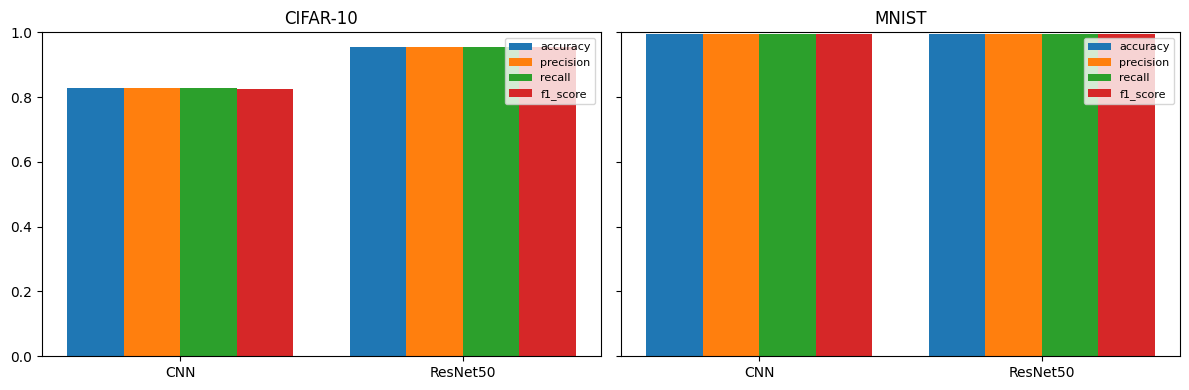

In [5]:
if results_df.empty:
    raise ValueError("Nenhum resultado carregado. Verifique os arquivos JSON em ../results.")

metrics = ["accuracy", "precision", "recall", "f1_score"]
datasets = results_df["dataset"].unique().tolist()
models = [m for m in ["CNN", "ResNet50"] if m in results_df["model"].unique()]

# Graficos de metricas por dataset
fig, axs = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 4), sharey=True)
if len(datasets) == 1:
    axs = [axs]

for ax, ds in zip(axs, datasets):
    sub = results_df[results_df["dataset"] == ds].set_index("model")
    sub = sub.loc[[m for m in models if m in sub.index]]
    x = np.arange(len(sub.index))
    width = 0.2
    for i, metric in enumerate(metrics):
        ax.bar(x + i * width, sub[metric].values, width, label=metric)
    ax.set_title(ds)
    ax.set_xticks(x + width * (len(metrics) - 1) / 2)
    ax.set_xticklabels(sub.index)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_66356\2293038563.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


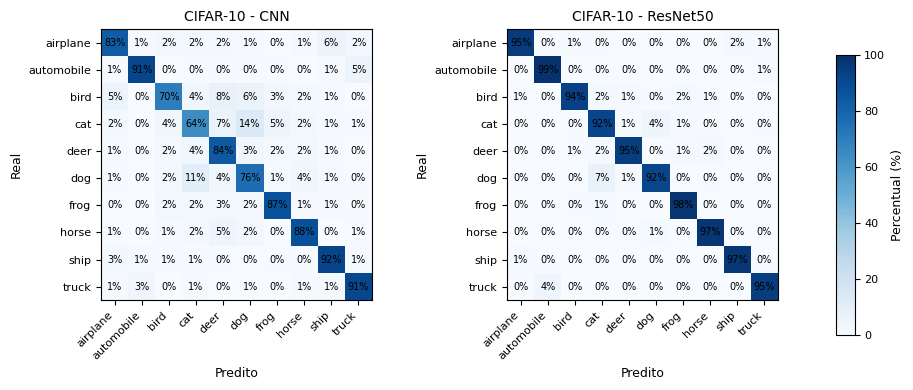

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_66356\2293038563.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


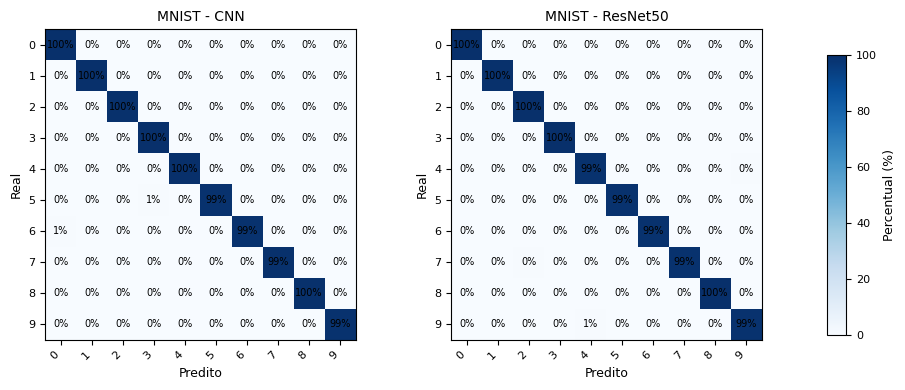

In [11]:
# Matrizes de confusao comparativas (um bloco por dataset)
for ds in datasets:
    ds_rows = results_df[results_df["dataset"] == ds]

    fig, axs = plt.subplots(1, len(models), figsize=(4 * len(models) + 1.5, 4))
    if len(models) == 1:
        axs = [axs]

    for ax, model in zip(axs, models):
        row = ds_rows[ds_rows["model"] == model].iloc[0]
        cm = np.array(row["confusion_matrix"], dtype=float)
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_percent = (cm / row_sums) * 100.0

        im = ax.imshow(cm_percent, vmin=0, vmax=100, cmap="Blues")
        ax.set_title(f"{ds} - {model}", fontsize=10)
        ax.set_xlabel("Predito", fontsize=9)
        ax.set_ylabel("Real", fontsize=9)
        class_names = row["class_names"]
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels(class_names, fontsize=8)
        if len(class_names) <= 10:
            for r in range(cm_percent.shape[0]):
                for c in range(cm_percent.shape[1]):
                    ax.text(c, r, f"{cm_percent[r, c]:.0f}%", ha="center", va="center", fontsize=7)

    fig.subplots_adjust(right=0.88)
    cax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Percentual (%)", fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    plt.tight_layout(rect=[0, 0, 0.88, 1])
    plt.show()